### Objective

**This project focuses on performing Exploratory Data Analysis (EDA) on a global COVID-19 dataset to understand the spread, severity, recovery trends, and regional impact of the pandemic. The dataset includes country-wise information such as confirmed cases, deaths, recoveries, active cases, new cases, weekly growth, WHO regions, and geographical coordinates.**

**The project began with data cleaning and preprocessing, where missing values, duplicate records, and incorrect data types were identified and handled to improve data quality. The cleaned dataset was then explored using statistical summaries and descriptive analysis to better understand the distribution of COVID-19 indicators.**

In [2]:
# Importing Libraries that would be used in this project

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Reading 2 CSV files and loading the COVID Dataset

df1=pd.read_csv('/kaggle/input/datasets/imdevskp/corona-virus-report/country_wise_latest.csv')
df2=pd.read_csv('/kaggle/input/datasets/imdevskp/corona-virus-report/covid_19_clean_complete.csv')


In [4]:
# Merging Data Horizontally using pd.merge()

merge=pd.DataFrame(pd.merge(df1,df2, how='inner'))
merge.head(10)

# If merging datasets vertically 
#merge1=pd.concat([df1, df2], ignore_index =True)
#merge1.head(10)

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region,Province/State,Lat,Long,Date
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean,NaN,33.93911,67.709953,2020-07-27
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe,NaN,41.15330,20.168300,2020-07-27
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa,NaN,28.03390,1.659600,2020-07-27
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe,NaN,42.50630,1.521800,2020-07-27
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa,NaN,-11.20270,17.873900,2020-07-27
5,Antigua and Barbuda,86,3,65,18,4,0,5,3.49,75.58,4.62,76,10,13.16,Americas,NaN,17.06080,-61.796400,2020-07-27
6,Argentina,167416,3059,72575,91782,4890,120,2057,1.83,43.35,4.21,130774,36642,28.02,Americas,NaN,-38.41610,-63.616700,2020-07-27
7,Armenia,37390,711,26665,10014,73,6,187,1.90,71.32,2.67,34981,2409,6.89,Europe,NaN,40.06910,45.038200,2020-07-27
8,Austria,20558,713,18246,1599,86,1,37,3.47,88.75,3.91,19743,815,4.13,Europe,NaN,47.51620,14.550100,2020-07-27
9,Azerbaijan,30446,423,23242,6781,396,6,558,1.39,76.34,1.82,27890,2556,9.16,Europe,NaN,40.14310,47.576900,2020-07-27


In [6]:
# DataType of Dataset
type(merge)

pandas.core.frame.DataFrame

In [7]:
# Returns rows and columns
merge.shape

(659, 19)

In [2]:
# Returns list of columns in the dataset
merge.columns.tolist()

NameError: name 'merge' is not defined

In [9]:
# Returns all values in a record per column

merge.values

array([['Afghanistan', 36263, 1269, ..., 33.93911, 67.709953,
        '2020-07-27'],
       ['Albania', 4880, 144, ..., 41.1533, 20.1683, '2020-07-27'],
       ['Algeria', 27973, 1163, ..., 28.0339, 1.6596, '2020-07-27'],
       ...,
       ['Yemen', 1691, 483, ..., 15.552727, 48.516388, '2020-07-27'],
       ['Zambia', 4552, 140, ..., -13.133897, 27.849332, '2020-07-27'],
       ['Zimbabwe', 2704, 36, ..., -19.015438, 29.154857, '2020-07-27']],
      dtype=object)

In [10]:
# Displays non-null values, datatypes, memory usage info, and count of rows and columns

merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 659 entries, 0 to 658
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          659 non-null    object 
 1   Confirmed               659 non-null    int64  
 2   Deaths                  659 non-null    int64  
 3   Recovered               659 non-null    int64  
 4   Active                  659 non-null    int64  
 5   New cases               659 non-null    int64  
 6   New deaths              659 non-null    int64  
 7   New recovered           659 non-null    int64  
 8   Deaths / 100 Cases      659 non-null    float64
 9   Recovered / 100 Cases   659 non-null    float64
 10  Deaths / 100 Recovered  659 non-null    float64
 11  Confirmed last week     659 non-null    int64  
 12  1 week change           659 non-null    int64  
 13  1 week % increase       659 non-null    float64
 14  WHO Region              659 non-null    ob

In [6]:
# Check for missing values in every column

merge.isna().sum()

Country/Region              0
Confirmed                   0
Deaths                      0
Recovered                   0
Active                      0
New cases                   0
New deaths                  0
New recovered               0
Deaths / 100 Cases          0
Recovered / 100 Cases       0
Deaths / 100 Recovered      0
Confirmed last week         0
1 week change               0
1 week % increase           0
WHO Region                  0
Province/State            658
Lat                         0
Long                        0
Date                        0
dtype: int64

In [16]:
# Check for missing value percentage

missing_val = (merge.isnull().sum()/len(merge))*100

missing_val.sort_values(ascending=False)

Country/Region            0.0
Confirmed                 0.0
Deaths                    0.0
Recovered                 0.0
Active                    0.0
New cases                 0.0
New deaths                0.0
New recovered             0.0
Deaths / 100 Cases        0.0
Recovered / 100 Cases     0.0
Deaths / 100 Recovered    0.0
Confirmed last week       0.0
1 week change             0.0
1 week % increase         0.0
WHO Region                0.0
Lat                       0.0
Long                      0.0
Date                      0.0
dtype: float64

In [5]:
# Dropping Province/State column as it has 99% null values 

merge.drop(columns='Province/State', inplace=True)


In [18]:
# Checking Duplicate Records
merge.duplicated().sum()      # No duplicate records

np.int64(0)

In [20]:
# Check DataType of each columns

merge.dtypes

Country/Region             object
Confirmed                   int64
Deaths                      int64
Recovered                   int64
Active                      int64
New cases                   int64
New deaths                  int64
New recovered               int64
Deaths / 100 Cases        float64
Recovered / 100 Cases     float64
Deaths / 100 Recovered    float64
Confirmed last week         int64
1 week change               int64
1 week % increase         float64
WHO Region                 object
Lat                       float64
Long                      float64
Date                       object
dtype: object

In [25]:
# Convert WHO Region columns from 'object' to 'Category' datatype to reduce memory usage
merge['WHO Region'] = merge['WHO Region'].astype('category')

In [39]:
# Checking unique number of values in each column

for col in merge.columns:
    print(f'Column Name :{col}, Unique values: {merge[col].nunique()}')

Column Name :Country/Region, Unique values: 180
Column Name :Confirmed, Unique values: 177
Column Name :Deaths, Unique values: 143
Column Name :Recovered, Unique values: 172
Column Name :Active, Unique values: 166
Column Name :New cases, Unique values: 116
Column Name :New deaths, Unique values: 38
Column Name :New recovered, Unique values: 100
Column Name :Deaths / 100 Cases, Unique values: 139
Column Name :Recovered / 100 Cases, Unique values: 171
Column Name :Deaths / 100 Recovered, Unique values: 150
Column Name :Confirmed last week, Unique values: 176
Column Name :1 week change, Unique values: 156
Column Name :1 week % increase, Unique values: 163
Column Name :WHO Region, Unique values: 6
Column Name :Lat, Unique values: 180
Column Name :Long, Unique values: 180
Column Name :Date, Unique values: 95


### ***Summary Statistics***

In [26]:
# describe() calculates summary statistics for all numeric columns.

merge.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,Lat,Long
count,6.590000e+02,659.000000,6.590000e+02,6.590000e+02,659.000000,659.000000,659.000000,659.000000,659.000000,659.00,6.590000e+02,659.000000,659.00000,659.000000,659.000000
mean,2.528683e+04,981.758725,1.488283e+04,9.422238e+03,339.397572,8.147193,264.236722,2.187390,61.795842,inf,2.259840e+04,2688.426404,4.54308,11.450858,27.250499
std,2.078245e+05,7589.572619,1.039944e+05,1.140456e+05,3084.699839,65.146652,2271.280723,2.995824,36.067204,NaN,1.835095e+05,25608.801014,16.87243,20.025732,68.255399
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,1.000000e+01,-47.000000,-3.84000,-40.900600,-102.552800
25%,2.300000e+01,0.000000,1.200000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,35.950000,0.00,2.300000e+01,0.000000,0.00000,-6.369028,-12.885800
50%,1.410000e+02,3.000000,9.400000e+01,2.400000e+01,0.000000,0.000000,0.000000,1.330000,74.840000,2.17,1.410000e+02,0.000000,0.00000,12.116500,19.145100
75%,1.624000e+03,27.500000,8.060000e+02,3.050000e+02,0.000000,0.000000,0.000000,3.900000,97.870000,6.48,1.444000e+03,12.000000,2.86000,24.215500,98.474271
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,28.560000,100.000000,inf,3.834677e+06,455582.000000,226.32000,71.706900,178.065000


In [ ]:
# for non-numerical columns

merge.describe(include='object')

In [27]:
# for numerical as well as non-numerical columns

merge.describe(include='all')

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region,Lat,Long,Date
count,659,6.590000e+02,659.000000,6.590000e+02,6.590000e+02,659.000000,659.000000,659.000000,659.000000,659.000000,659.00,6.590000e+02,659.000000,659.00000,659,659.000000,659.000000,659
unique,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN,NaN,95
top,Timor-Leste,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Africa,NaN,NaN,2020-07-27
freq,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203,NaN,NaN,180
mean,NaN,2.528683e+04,981.758725,1.488283e+04,9.422238e+03,339.397572,8.147193,264.236722,2.187390,61.795842,inf,2.259840e+04,2688.426404,4.54308,NaN,11.450858,27.250499,NaN
std,NaN,2.078245e+05,7589.572619,1.039944e+05,1.140456e+05,3084.699839,65.146652,2271.280723,2.995824,36.067204,NaN,1.835095e+05,25608.801014,16.87243,NaN,20.025732,68.255399,NaN
min,NaN,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,1.000000e+01,-47.000000,-3.84000,NaN,-40.900600,-102.552800,NaN
25%,NaN,2.300000e+01,0.000000,1.200000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,35.950000,0.00,2.300000e+01,0.000000,0.00000,NaN,-6.369028,-12.885800,NaN
50%,NaN,1.410000e+02,3.000000,9.400000e+01,2.400000e+01,0.000000,0.000000,0.000000,1.330000,74.840000,2.17,1.410000e+02,0.000000,0.00000,NaN,12.116500,19.145100,NaN
75%,NaN,1.624000e+03,27.500000,8.060000e+02,3.050000e+02,0.000000,0.000000,0.000000,3.900000,97.870000,6.48,1.444000e+03,12.000000,2.86000,NaN,24.215500,98.474271,NaN


In [ ]:
# Average of all numeric column

merge.mean(numeric_only=True)

In [ ]:
# Median of all numeric column

merge.median(numeric_only=True)

In [ ]:
# Mode of all numeric column

merge.mode(numeric_only=True)

In [ ]:
# Maximum of all numeric column

merge.max(numeric_only=True)

In [ ]:
# Minimum of all numeric column

merge.min(numeric_only=True)

In [ ]:
# Standard Deviation of all numeric column

merge.std(numeric_only=True)

### ***Business questions and Visualizations***

What is the total number of death cases per confirmed case? 

In [7]:
merge['Total confirmed cases']= merge['Confirmed']+merge['New cases']
merge['Total confirmed cases']

0      36369
1       4997
2      28589
3        917
4        968
       ...  
654       10
655       10
656     1701
657     4623
658     2896
Name: Total confirmed cases, Length: 659, dtype: int64

In [48]:
merge['Total Death cases']=merge['Deaths']+merge['New deaths']
merge['Total Death cases']

0      1279
1       150
2      1171
3        52
4        42
       ... 
654       1
655       1
656     487
657     141
658      38
Name: Total Death cases, Length: 659, dtype: int64

In [47]:
per=(merge['Total Death cases'].sum()/merge['Total confirmed cases'].sum())*100
print(f'Total percentage of death per 100 cases: {per:.2f}')

Total percentage of death per 100 cases: 3.86


Which are the top 10 countries with the highest records of recovered cases?

In [49]:
merge['total_recovered']=merge['Recovered']+merge['New recovered']
merge['total_recovered']

0      25216
1       2808
2      19586
3        803
4        242
       ...  
654        8
655        8
656      869
657     3280
658      566
Name: total_recovered, Length: 659, dtype: int64

In [53]:
data1=merge.groupby('Country/Region')['total_recovered'].sum().sort_values(ascending=False).head(10)
data1

Country/Region
Brazil          1880369
US              1353745
India            984764
Russia           605326
Spain            601504
Chile            321813
Mexico           312398
South Africa     284773
Peru             277244
Iran             257075
Name: total_recovered, dtype: int64

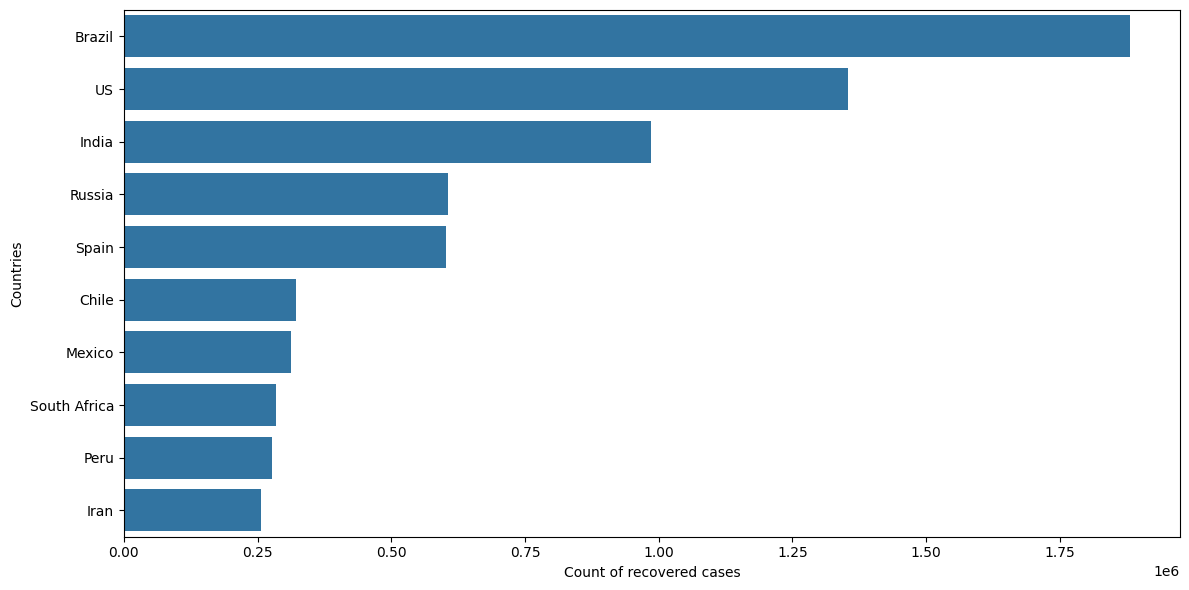

In [58]:
plt.figure(figsize=(12,6))
sns.barplot(x=data1.values, y=data1.index)
plt.xlabel("Count of recovered cases")
plt.ylabel("Countries")
plt.tight_layout()
plt.show()

Which WHO region has the highest total number of confirmed COVID-19 cases?

In [9]:
merge['Total confirmed cases'].sum()

np.int64(16887683)

In [12]:
region_wise=merge.groupby('WHO Region')['Total confirmed cases'].sum().sort_values(ascending=False)
region_wise

WHO Region
Americas                 8874705
Europe                   3550669
South-East Asia          1886546
Eastern Mediterranean    1503154
Africa                    873440
Western Pacific           199169
Name: Total confirmed cases, dtype: int64

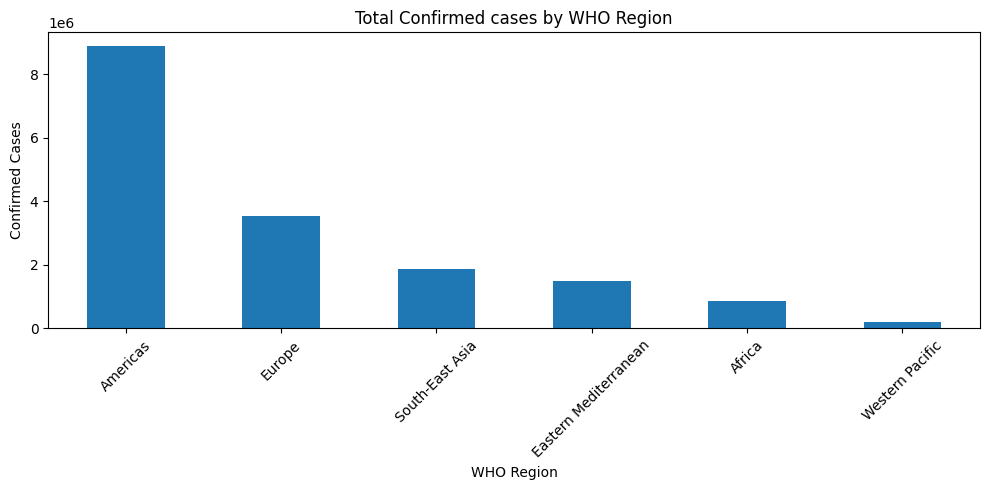

In [14]:
region_wise.plot(kind='bar', figsize=(10,5))
plt.title("Total Confirmed cases by WHO Region")
plt.xlabel('WHO Region')
plt.ylabel('Confirmed Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Which countries experienced the highest increase in cases during the last week?

In [22]:
weekly_growth= merge.groupby("Country/Region")['1 week change'].sum().sort_values(ascending=False).head(10)
weekly_growth

Country/Region
US              455582
India           324735
Brazil          323729
South Africa     78901
Colombia         53096
Mexico           46093
Russia           40468
Argentina        36642
Peru             32036
Spain            30340
Name: 1 week change, dtype: int64

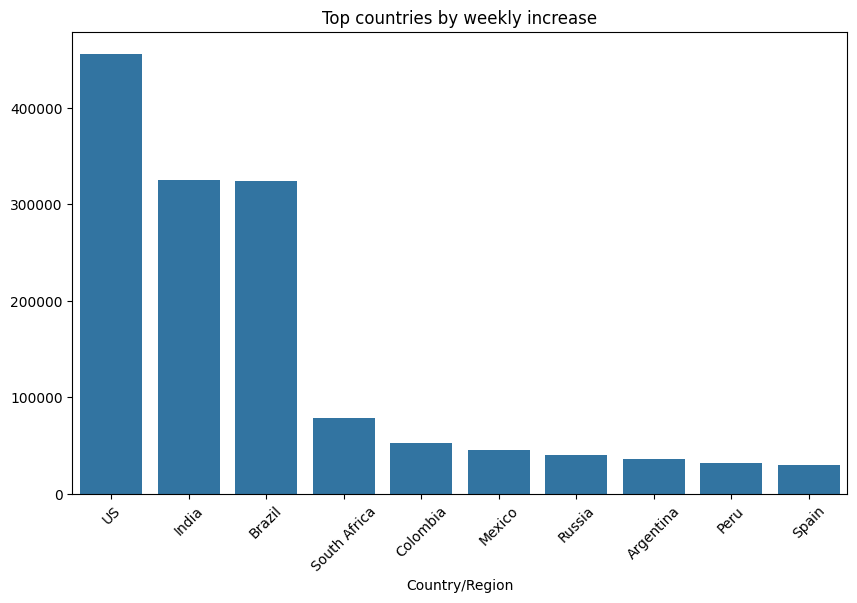

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(x= weekly_growth.index, y=weekly_growth.values)
plt.title("Top countries by weekly increase")
plt.xticks(rotation=45)
plt.show()

Is there any relationship between confirmed cases and death?

In [27]:
corr=merge['Confirmed'].corr(merge['Deaths'])
print(f'Correlation: {corr:.2f}')       # Close to Strong postive relation


Correlation: 0.95


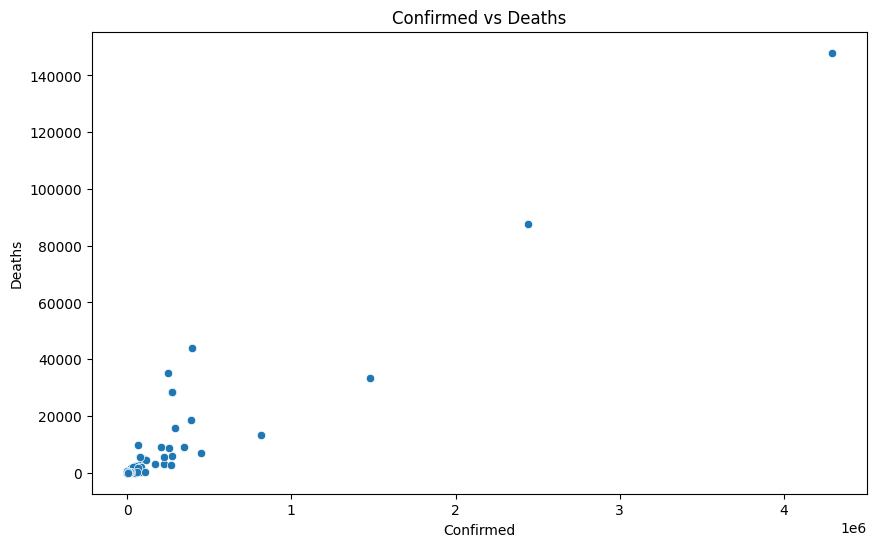

In [29]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=merge, x="Confirmed", y="Deaths")
plt.title("Confirmed vs Deaths")
plt.show()

Which WHO region has the highest average recovery rate?

In [31]:
rec_rate=merge.groupby("WHO Region")["Recovered / 100 Cases"].mean().sort_values(ascending=False)
rec_rate

WHO Region
Western Pacific          88.446716
Americas                 87.360822
Europe                   85.451624
Eastern Mediterranean    66.593182
Africa                   48.832118
South-East Asia           6.413846
Name: Recovered / 100 Cases, dtype: float64

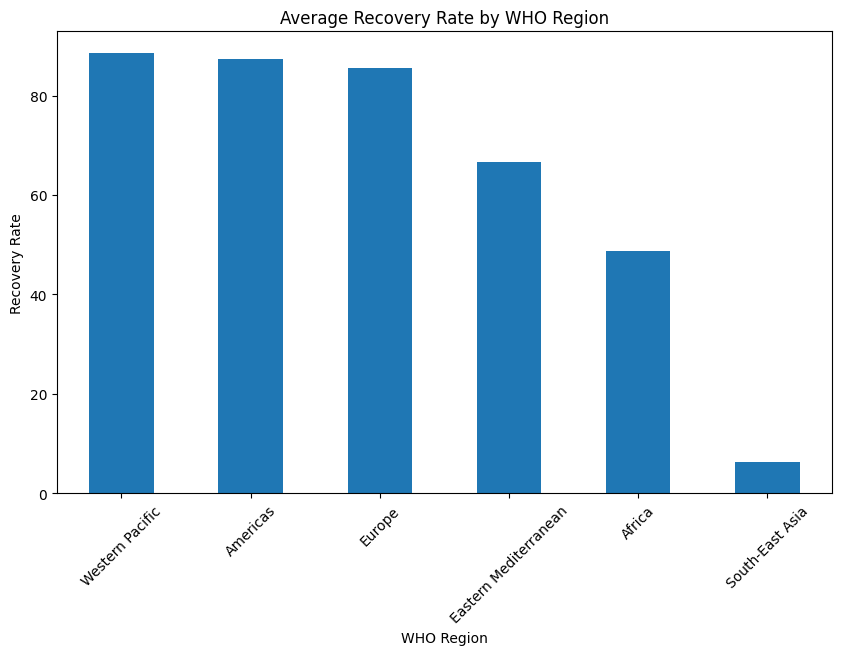

In [33]:
rec_rate.plot(kind='bar', figsize=(10,6))
plt.title("Average Recovery Rate by WHO Region")
plt.ylabel('Recovery Rate')
plt.xlabel('WHO Region')
plt.xticks(rotation=45)
plt.show()
              
              

### Conclusion

***Several business questions were answered using Pandas by applying grouping, sorting, aggregation, and correlation techniques. These analyses identified the WHO regions with the highest confirmed cases, countries with the highest death rates and active cases, regions with better recovery rates, and countries experiencing rapid weekly increases in infections. Correlation analysis was also performed to study the relationship between confirmed cases and deaths.***

***We also used Matplotlib and Seaborn visualizations such as bar charts, horizontal bar charts, and scatter plots. 
Overall, this EDA project demonstrates how Python-based data analysis techniques can transform raw COVID-19 data into meaningful insights. The findings can help governments, healthcare organizations, and policymakers understand disease patterns, identify high-risk regions, allocate healthcare resources effectively, and support data-driven decision-making during public health emergencies.***